# LSTM Baseline Workflow for ML-Based ATS

This notebook demonstrates a minimal, educational baseline for forecasting stock prices with an LSTM in a strictly chronological setting.

The goal is to show:

1. how to load stock data,
2. how to split it into train, validation, and test periods without temporal leakage,
3. how to build LSTM input sequences,
4. how to train and validate a forecasting model,
5. how to generate and save prediction timelines for downstream ATS evaluation.

The saved prediction timelines are then used in Notebook 2, where forecasting outputs are converted into simple trading decisions.

In [1]:
import sys
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.append(str(SRC_ROOT))

from data.loaders import download_stock_data, load_local_stock_csv
from data.splits import make_date_splits
from data.sequence_builder import build_lstm_sequences
from models.lstm.model import LSTM
from pipeline.prediction_timelines import build_prediction_timeline

print("Project root:", PROJECT_ROOT)

2026-04-13 15:09:52.788567: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-13 15:09:52.796895: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776085792.805990 3512447 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776085792.808914 3512447 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-13 15:09:52.818823: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Project root: /home/advije/ml-ats-baseline


## Reproducibility and configuration

We use a fixed stock universe and fixed date boundaries so that the workflow is easy to follow and reproduce.

This repository is meant to be a clean educational baseline, not a large experimental framework.

In [2]:
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

try:
    import tensorflow as tf
    tf.random.set_seed(RANDOM_SEED)
except Exception:
    pass

In [3]:
SELECTED_TICKERS = [
    "XOM",
    "AMZN",
    "AAPL",
    "JPM",
    "TSLA",
    "GOOGL",
    "WMT",
    "PG",
    "KO",
    "JNJ",
]

FEATURE_COLS = ["open", "high", "low", "close", "volume"]
TARGET_COL = "open"
SEQUENCE_LENGTH = 50

START_DATE = "2013-01-01"
END_DATE = "2026-04-01"

TRAIN_END = "2020-12-31"
VAL_END = "2022-12-31"

DATA_DIR = PROJECT_ROOT / "data" / "prices"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
MODELS_DIR = OUTPUTS_DIR / "models"
METRICS_DIR = OUTPUTS_DIR / "metrics"
PREDICTIONS_DIR = OUTPUTS_DIR / "predictions"

DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

## Selected stock universe

We use a fixed set of 10 large-cap stocks across multiple sectors:

- XOM
- AMZN
- AAPL
- JPM
- TSLA
- GOOGL
- WMT
- PG
- KO
- JNJ

Using a fixed universe keeps the baseline consistent and makes downstream portfolio evaluation easier to understand.

## Download or refresh raw price data

If price CSVs are not already present locally, this cell downloads them.

If they already exist, `overwrite=False` prevents accidental replacement.

In [4]:
download_stock_data(
    tickers=SELECTED_TICKERS,
    start_date=START_DATE,
    end_date=END_DATE,
    data_folder=DATA_DIR,
    overwrite=False,
)

XOM: already exists. Skipping.
AMZN: already exists. Skipping.
AAPL: already exists. Skipping.
JPM: already exists. Skipping.
TSLA: already exists. Skipping.
GOOGL: already exists. Skipping.
WMT: already exists. Skipping.
PG: already exists. Skipping.
KO: already exists. Skipping.
JNJ: already exists. Skipping.


[PosixPath('/home/advije/ml-ats-baseline/data/prices/XOM.csv'),
 PosixPath('/home/advije/ml-ats-baseline/data/prices/AMZN.csv'),
 PosixPath('/home/advije/ml-ats-baseline/data/prices/AAPL.csv'),
 PosixPath('/home/advije/ml-ats-baseline/data/prices/JPM.csv'),
 PosixPath('/home/advije/ml-ats-baseline/data/prices/TSLA.csv'),
 PosixPath('/home/advije/ml-ats-baseline/data/prices/GOOGL.csv'),
 PosixPath('/home/advije/ml-ats-baseline/data/prices/WMT.csv'),
 PosixPath('/home/advije/ml-ats-baseline/data/prices/PG.csv'),
 PosixPath('/home/advije/ml-ats-baseline/data/prices/KO.csv'),
 PosixPath('/home/advije/ml-ats-baseline/data/prices/JNJ.csv')]

## Inspect one example stock

Before running the full baseline over all stocks, we inspect one ticker to make the workflow more concrete.

In [15]:
example_ticker = "AMZN"
csv_path = DATA_DIR / f"{example_ticker}.csv"

df = load_local_stock_csv(csv_path)

print(df.head())
print()
print(df.tail())
print()
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

        date       open       high        low      close    volume ticker
0 2018-01-02  58.599998  59.500000  58.525501  59.450500  53890000   AMZN
1 2018-01-03  59.415001  60.274502  59.415001  60.209999  62176000   AMZN
2 2018-01-04  60.250000  60.793499  60.233002  60.479500  60442000   AMZN
3 2018-01-05  60.875500  61.457001  60.500000  61.457001  70894000   AMZN
4 2018-01-08  61.799999  62.653999  61.601501  62.343498  85590000   AMZN

           date        open        high         low       close    volume  \
2067 2026-03-25  211.559998  213.070007  209.899994  211.710007  36388800   
2068 2026-03-26  210.610001  212.889999  207.119995  207.539993  46746000   
2069 2026-03-27  206.460007  206.600006  199.139999  199.339996  56009800   
2070 2026-03-30  201.479996  203.800003  199.979996  200.949997  46373800   
2071 2026-03-31  204.850006  210.279999  204.139999  208.270004  58470100   

     ticker  
2067   AMZN  
2068   AMZN  
2069   AMZN  
2070   AMZN  
2071   AMZN  

Shape: 

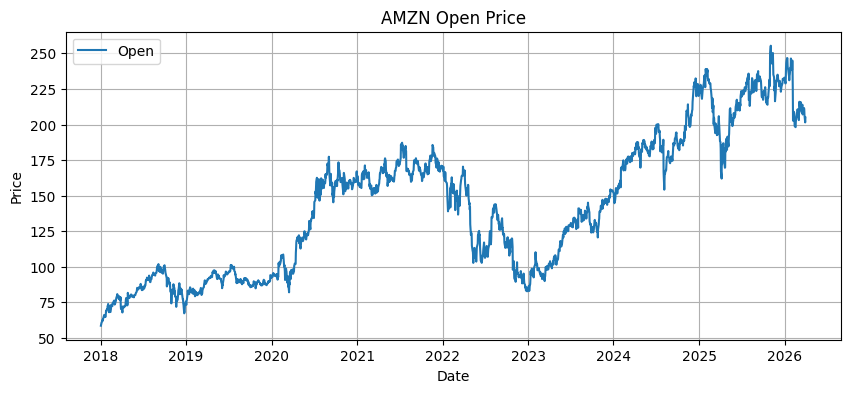

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(df["date"], df[TARGET_COL], label=TARGET_COL.capitalize())
plt.title(f"{example_ticker} {TARGET_COL.capitalize()} Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.legend()
plt.show()

## Chronological split

The split is strictly chronological:

- training data comes first,
- validation comes after training,
- test comes last.

This avoids temporal leakage and better reflects how forecasting would work in practice.

In [17]:
train_df, val_df, test_df = make_date_splits(
    df,
    train_end=TRAIN_END,
    val_end=VAL_END,
    date_col="date",
)

print("Train:", train_df["date"].min(), "->", train_df["date"].max(), "| rows:", len(train_df))
print("Validation:", val_df["date"].min(), "->", val_df["date"].max(), "| rows:", len(val_df))
print("Test:", test_df["date"].min(), "->", test_df["date"].max(), "| rows:", len(test_df))

train: 2018-01-02 → 2020-12-31 (756 rows)
val:   2021-01-04 → 2022-12-30 (503 rows)
test:  2023-01-03 → 2026-03-31 (813 rows)
Train: 2018-01-02 00:00:00 -> 2020-12-31 00:00:00 | rows: 756
Validation: 2021-01-04 00:00:00 -> 2022-12-30 00:00:00 | rows: 503
Test: 2023-01-03 00:00:00 -> 2026-03-31 00:00:00 | rows: 813


## Build LSTM input sequences

Each training example uses a rolling window of past observations with length `SEQUENCE_LENGTH`.

The target is the next value of the selected target column.

In [18]:
X_train, y_train, train_dates = build_lstm_sequences(
    train_df,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    sequence_length=SEQUENCE_LENGTH,
)

X_val, y_val, val_dates = build_lstm_sequences(
    val_df,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    sequence_length=SEQUENCE_LENGTH,
)

X_test, y_test, test_dates = build_lstm_sequences(
    test_df,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    sequence_length=SEQUENCE_LENGTH,
)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:", X_val.shape, "| y_val:", y_val.shape)
print("X_test:", X_test.shape, "| y_test:", y_test.shape)

X_train: (706, 50, 5) | y_train: (706,)
X_val: (453, 50, 5) | y_val: (453,)
X_test: (763, 50, 5) | y_test: (763,)


## Fixed baseline model configuration

We use one fixed LSTM configuration for the public baseline.

The goal here is clarity and reproducibility, not aggressive hyperparameter optimization.

In [19]:
MODEL_CONFIG = {
    "sequence_length": SEQUENCE_LENGTH,
    "n_features": len(FEATURE_COLS),
    "lstm_units_1": 128,
    "lstm_units_2": 64,
    "dropout": 0.3,
    "dense_units": 32,
    "learning_rate": 1e-3,
}

In [20]:
model = LSTM(**MODEL_CONFIG)

history = model.fit(
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=50,
    batch_size=32,
    verbose=1,
    model_ckpt_path=None,
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0576 - mae: 0.1624 - val_loss: 0.0049 - val_mae: 0.0550 - learning_rate: 0.0010
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0026 - mae: 0.0388 - val_loss: 0.0058 - val_mae: 0.0594 - learning_rate: 0.0010
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0017 - mae: 0.0301 - val_loss: 0.0043 - val_mae: 0.0508 - learning_rate: 0.0010
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0015 - mae: 0.0285 - val_loss: 0.0041 - val_mae: 0.0494 - learning_rate: 0.0010
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0016 - mae: 0.0296 - val_loss: 0.0055 - val_mae: 0.0605 - learning_rate: 0.0010
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0023 - mae: 0.0352 - val_loss: 0.0038 - val_mae: 0.0477 - learning_rate: 0.0010
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0015 - mae: 0.0279 - val_loss: 0.0037 - val_mae: 0.0469 - learning_rate: 0.0010
Epoch 8/50
23

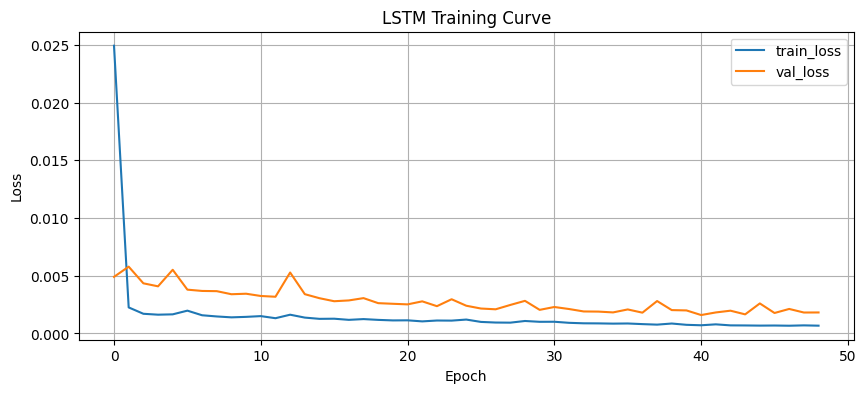

In [21]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(10, 4))
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.title("LSTM Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

In [22]:
y_val_pred = np.asarray(model.predict(X_val)).reshape(-1)
y_test_pred = np.asarray(model.predict(X_test)).reshape(-1)

y_val = np.asarray(y_val).reshape(-1)
y_test = np.asarray(y_test).reshape(-1)

## Build prediction timelines

We now convert raw forecasts into structured prediction timelines.

These timelines keep each prediction aligned with its corresponding date and include simple return-based fields that will later be used in the ATS notebook.

In [23]:
val_pred_df = build_prediction_timeline(
    dates=val_dates,
    raw_df_split=val_df,
    y_true=y_val,
    y_pred=y_val_pred,
    price_col=TARGET_COL,
)

test_pred_df = build_prediction_timeline(
    dates=test_dates,
    raw_df_split=test_df,
    y_true=y_test,
    y_pred=y_test_pred,
    price_col=TARGET_COL,
)

print(val_pred_df.head())
print()
print(test_pred_df.head())

        date      y_true      y_pred   prev_open  true_return  pred_return  \
0 2021-03-17  153.660995  156.563828  155.248505    -0.010226     0.008472   
1 2021-03-18  155.050003  156.874176  153.660995     0.009039     0.020911   
2 2021-03-19  151.461502  156.228378  155.050003    -0.023144     0.007600   
3 2021-03-22  153.392502  155.267914  151.461502     0.012749     0.025131   
4 2021-03-23  156.350006  155.443497  153.392502     0.019281     0.013371   

   true_direction  pred_direction  
0               0               1  
1               1               1  
2               0               1  
3               1               1  
4               1               1  

        date      y_true     y_pred  prev_open  true_return  pred_return  \
0 2023-03-16   95.750000  93.958061  93.220001     0.027140     0.007917   
1 2023-03-17   99.790001  95.286972  95.750000     0.042193    -0.004836   
2 2023-03-20   98.410004  96.929893  99.790001    -0.013829    -0.028661   
3 2023-03-

In [24]:
val_rmse = np.sqrt(np.mean((y_val - y_val_pred) ** 2))
test_rmse = np.sqrt(np.mean((y_test - y_test_pred) ** 2))

val_mae = np.mean(np.abs(y_val - y_val_pred))
test_mae = np.mean(np.abs(y_test - y_test_pred))

pd.DataFrame([
    {
        "ticker": example_ticker,
        "val_rmse": val_rmse,
        "test_rmse": test_rmse,
        "val_mae": val_mae,
        "test_mae": test_mae,
    }
])

,ticker,val_rmse,test_rmse,val_mae,test_mae
0,AMZN,4.399899,12.105007,3.325043,8.99225


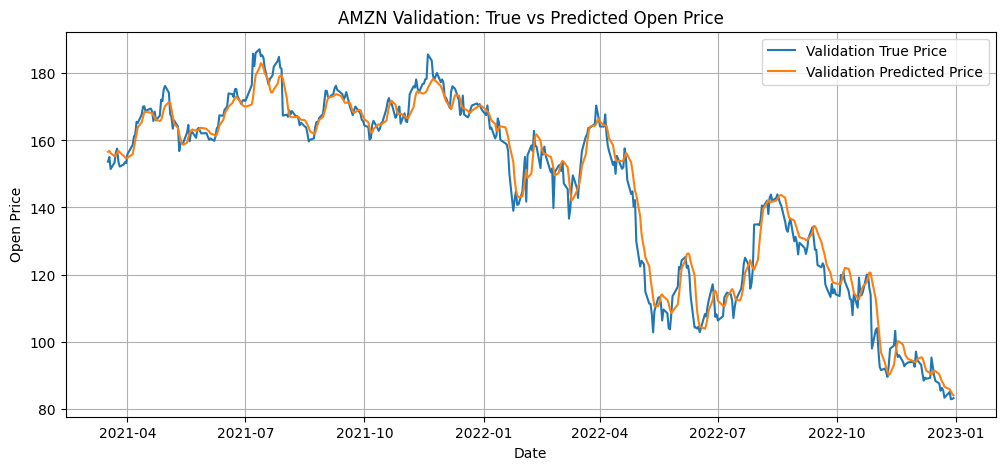

In [26]:
plt.figure(figsize=(12, 5))
plt.plot(val_pred_df["date"], val_pred_df["y_true"], label="Validation True Price")
plt.plot(val_pred_df["date"], val_pred_df["y_pred"], label="Validation Predicted Price")

plt.title(f"{example_ticker} Validation: True vs Predicted {TARGET_COL.capitalize()} Price")
plt.xlabel("Date")
plt.ylabel(f"{TARGET_COL.capitalize()} Price")
plt.grid(True)
plt.legend()
plt.show()

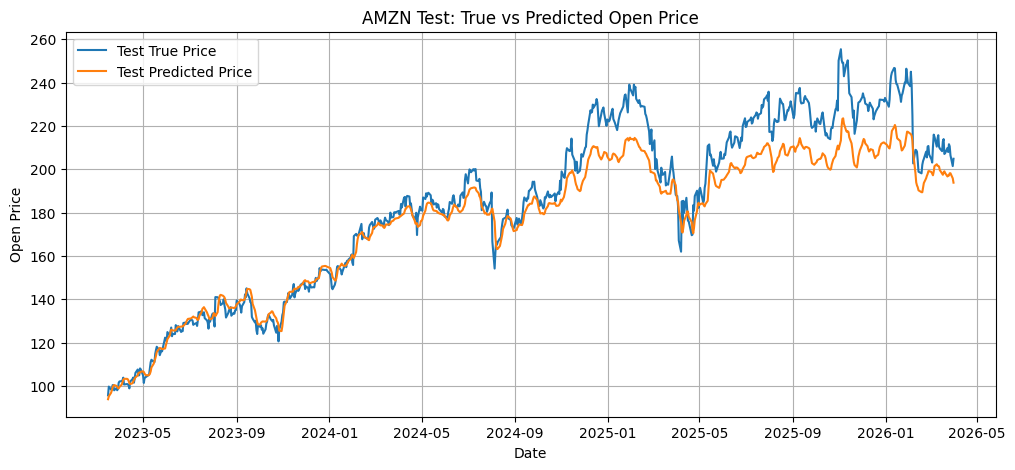

In [27]:
plt.figure(figsize=(12, 5))
plt.plot(test_pred_df["date"], test_pred_df["y_true"], label="Test True Price")
plt.plot(test_pred_df["date"], test_pred_df["y_pred"], label="Test Predicted Price")

plt.title(f"{example_ticker} Test: True vs Predicted {TARGET_COL.capitalize()} Price")
plt.xlabel("Date")
plt.ylabel(f"{TARGET_COL.capitalize()} Price")
plt.grid(True)
plt.legend()
plt.show()

In [28]:
summary_rows = []

for ticker in SELECTED_TICKERS:
    print(f"Processing {ticker} ...")

    csv_path = DATA_DIR / f"{ticker}.csv"
    df = load_local_stock_csv(csv_path)

    train_df, val_df, test_df = make_date_splits(
        df,
        train_end=TRAIN_END,
        val_end=VAL_END,
        date_col="date",
    )

    X_train, y_train, train_dates = build_lstm_sequences(
        train_df,
        feature_cols=FEATURE_COLS,
        target_col=TARGET_COL,
        sequence_length=SEQUENCE_LENGTH,
    )
    X_val, y_val, val_dates = build_lstm_sequences(
        val_df,
        feature_cols=FEATURE_COLS,
        target_col=TARGET_COL,
        sequence_length=SEQUENCE_LENGTH,
    )
    X_test, y_test, test_dates = build_lstm_sequences(
        test_df,
        feature_cols=FEATURE_COLS,
        target_col=TARGET_COL,
        sequence_length=SEQUENCE_LENGTH,
    )

    model = LSTM(**MODEL_CONFIG)
    history = model.fit(
        X_train,
        y_train,
        X_val,
        y_val,
        epochs=50,
        batch_size=32,
        verbose=0,
        model_ckpt_path=None,
    )

    y_val_pred = np.asarray(model.predict(X_val)).reshape(-1)
    y_test_pred = np.asarray(model.predict(X_test)).reshape(-1)

    y_val = np.asarray(y_val).reshape(-1)
    y_test = np.asarray(y_test).reshape(-1)

    val_pred_df = build_prediction_timeline(
        dates=val_dates,
        raw_df_split=val_df,
        y_true=y_val,
        y_pred=y_val_pred,
        price_col=TARGET_COL,
    )

    test_pred_df = build_prediction_timeline(
        dates=test_dates,
        raw_df_split=test_df,
        y_true=y_test,
        y_pred=y_test_pred,
        price_col=TARGET_COL,
    )

    val_pred_df.to_csv(PREDICTIONS_DIR / f"{ticker}_val_predictions.csv", index=False)
    test_pred_df.to_csv(PREDICTIONS_DIR / f"{ticker}_test_predictions.csv", index=False)

    val_rmse = np.sqrt(np.mean((y_val - y_val_pred) ** 2))
    test_rmse = np.sqrt(np.mean((y_test - y_test_pred) ** 2))
    val_mae = np.mean(np.abs(y_val - y_val_pred))
    test_mae = np.mean(np.abs(y_test - y_test_pred))

    summary_rows.append({
        "ticker": ticker,
        "val_rmse": val_rmse,
        "test_rmse": test_rmse,
        "val_mae": val_mae,
        "test_mae": test_mae,
        "n_train": len(X_train),
        "n_val": len(X_val),
        "n_test": len(X_test),
    })

    print(f"Saved predictions for {ticker}")

summary_df = pd.DataFrame(summary_rows).sort_values("ticker").reset_index(drop=True)
summary_df.to_csv(METRICS_DIR / "lstm_baseline_summary.csv", index=False)

with open(MODELS_DIR / "baseline_lstm_config.json", "w") as f:
    json.dump(MODEL_CONFIG, f, indent=2)

print("\nFinished all selected tickers.")
print("Saved summary to:", METRICS_DIR / "lstm_baseline_summary.csv")

summary_df

Processing XOM ...
train: 2018-01-02 → 2020-12-31 (756 rows)
val:   2021-01-04 → 2022-12-30 (503 rows)
test:  2023-01-03 → 2026-03-31 (813 rows)

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 12.
Saved predictions for XOM
Processing AMZN ...
train: 2018-01-02 → 2020-12-31 (756 rows)
val:   2021-01-04 → 2022-12-30 (503 rows)
test:  2023-01-03 → 2026-03-31 (813 rows)

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 31: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 40: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 44: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
Epoch 44: early stopping
Restoring model weights from 

,ticker,val_rmse,test_rmse,val_mae,test_mae,n_train,n_val,n_test
0,AAPL,6.407867,36.153736,4.993938,30.008675,706,453,763
1,AMZN,6.579963,24.350603,5.145328,18.653303,706,453,763
2,GOOGL,10.447709,66.376579,8.347334,46.559898,706,453,763
3,JNJ,2.729836,8.309581,2.250486,4.339159,706,453,763
4,JPM,3.305805,24.223808,2.626294,17.677969,706,453,763
5,KO,1.505585,2.742199,1.173282,2.269228,706,453,763
6,PG,2.809587,3.121427,2.085755,2.430025,706,453,763
7,TSLA,17.815128,22.922798,13.669126,17.048468,706,453,763
8,WMT,0.985879,14.814782,0.668527,10.520750,706,453,763
9,XOM,3.876090,10.289950,2.906158,8.123571,706,453,763
